# Monte Carlo Techniques
## Neutron Transport and Scattering Through a Shielding Layer

**Notebook version:** saved-output analysis notebook

### Project aim and physical context

Thermal neutrons travelling through matter undergo two main stochastic processes: **absorption**, where the neutron is removed, and **scattering**, where it survives but changes direction. These processes are central to radiation shielding because a useful shield should reduce the transmitted neutron flux, while the balance between reflection and absorption depends strongly on the material.

Monte Carlo simulation is appropriate because individual neutron histories are random, but measurable quantities such as transmission, reflection, and absorption are statistical averages over many histories. Analytical formulae are simple only in limiting cases, such as pure absorption without scattering. Once scattering is included, the neutron performs a three-dimensional random walk and the slab boundaries become important.

This notebook is organised as follows:

1. Check the quality of uniform random numbers and demonstrate spectral artefacts from a poor generator.
2. Generate exponentially distributed free paths and verify the water attenuation length without scattering.
3. Generate isotropic directions and isotropic exponentially distributed steps.
4. Compute material properties from microscopic cross-sections.
5. Simulate neutron random walks through finite slabs.
6. Estimate absorption, reflection, and transmission probabilities with uncertainties.
7. Fit attenuation lengths from transmission curves.
8. Extend the method to two adjacent materials using Woodcock tracking.

The notebook uses vectorised NumPy calculations for the Monte Carlo statistics and includes 3D visual checks where they are useful for assessing the random sampling. Matplotlib inline output is used so the figures are saved inside the notebook and remain visible when opened or exported.


In [1]:
import math
import time
from dataclasses import dataclass

import numpy as np

# Inline backend is used for the saved-output copy so plots are embedded in the notebook.
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

RNG = np.random.default_rng(20762)
FAST_REMOTE_RUN = True
NOTEBOOK_VERSION = "saved_output_analysis"
print(f"Notebook version: {NOTEBOOK_VERSION}")

plt.rcParams.update({
    "figure.figsize": (8.5, 5.0),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "legend.frameon": False,
})

def display_table(rows, digits=4):
    # Display a small table without importing pandas.
    if isinstance(rows, dict):
        rows = [rows]
    headers = list(rows[0].keys())
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |",
    ]
    for row in rows:
        values = []
        for header in headers:
            value = row[header]
            if isinstance(value, float):
                values.append(f"{value:.{digits}g}")
            else:
                values.append(str(value))
        lines.append("| " + " | ".join(values) + " |")
    display(Markdown("\n".join(lines)))

def show_fig():
    plt.show()
    plt.close("all")

start_time = time.perf_counter()


Notebook version: saved_output_analysis


## 1. Random Number Generation

Monte Carlo methods require random numbers that are uniformly distributed over a chosen interval. Here I test `numpy.random.uniform()` on the interval \([-2,3]\). For a continuous uniform distribution,

\[
\mu = \frac{a+b}{2}, \qquad \sigma^2 = \frac{(b-a)^2}{12}.
\]

The numerical sample mean and variance should approach these values as the number of samples increases.

| N | sample mean | expected mean | sample variance | expected variance | minimum | maximum |
| --- | --- | --- | --- | --- | --- | --- |
| 100000 | 0.5005 | 0.5 | 2.084 | 2.083 | -2 | 3 |

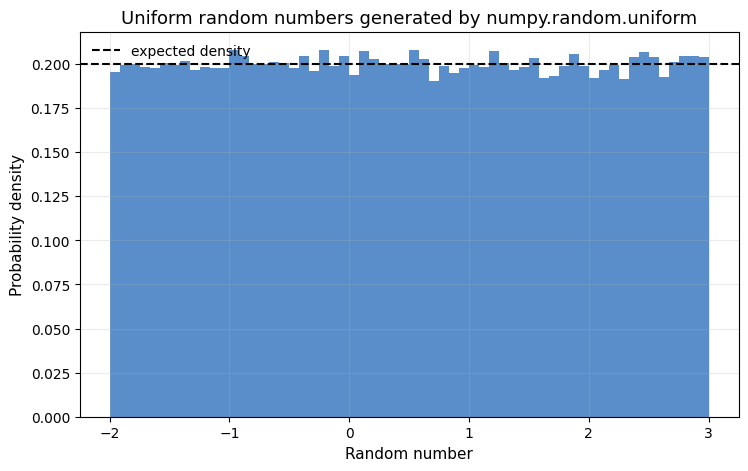

In [2]:
def uniform_diagnostic(rng, n=100_000, low=-2.0, high=3.0):
    values = rng.uniform(low, high, n)
    expected_mean = 0.5 * (low + high)
    expected_var = (high - low) ** 2 / 12
    return values, {
        "N": n,
        "sample mean": values.mean(),
        "expected mean": expected_mean,
        "sample variance": values.var(ddof=1),
        "expected variance": expected_var,
        "minimum": values.min(),
        "maximum": values.max(),
    }


uniform_values, uniform_stats = uniform_diagnostic(RNG)
display_table(uniform_stats)

fig, ax = plt.subplots()
ax.hist(uniform_values, bins=60, density=True, color="#2a6fbb", alpha=0.78)
ax.axhline(1 / 5, color="black", linestyle="--", label="expected density")
ax.set_xlabel("Random number")
ax.set_ylabel("Probability density")
ax.set_title("Uniform random numbers generated by numpy.random.uniform")
ax.legend()
show_fig()

## 2. Three-Dimensional Random Points and Spectral Issues

The next test uses triples \((x,y,z)\) generated independently from a uniform distribution. A good generator should fill the cube without visible planes or bands. For comparison, I also use a deliberately poor linear congruential generator (LCG) with a small modulus. This reproduces the same type of spectral problem demonstrated by the Blackboard `randssp.ipynb` exercise, while keeping this notebook self-contained. The poor generator is not used in the physics simulation; it is included only to illustrate spectral artefacts.

The scatter plots below show the three-dimensional point clouds directly. They are kept to a moderate number of points so that the notebook remains responsive while still revealing the spectral structure of a poor generator.

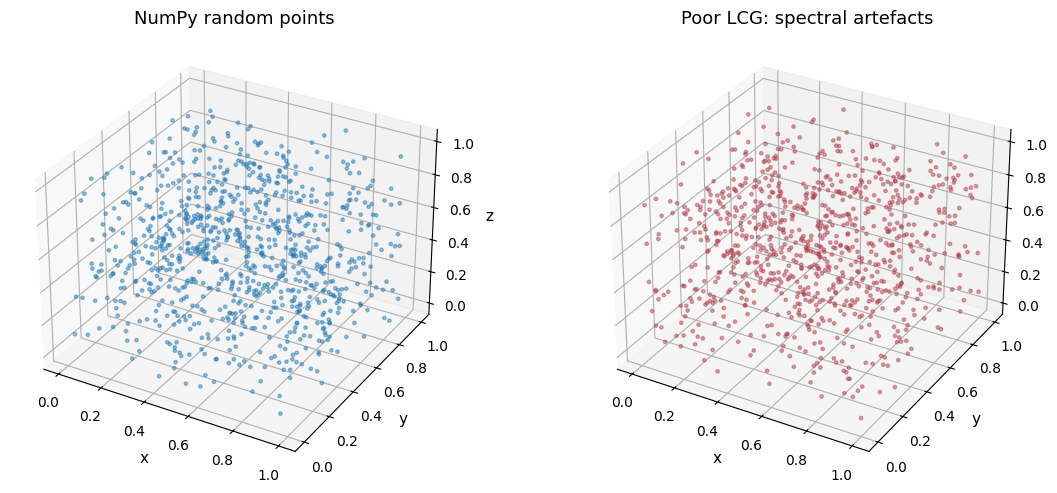

In [3]:
def random_points_3d(rng, n=900):
    return rng.uniform(0.0, 1.0, size=(n, 3))


def poor_lcg_points(n=900):
    modulus = 2**16
    a = 137
    c = 187
    x = 1
    values = np.empty(3 * n)
    for i in range(3 * n):
        x = (a * x + c) % modulus
        values[i] = x / modulus
    return values.reshape(n, 3)


good_points = random_points_3d(RNG)
bad_points = poor_lcg_points()

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection="3d")
ax1.scatter(good_points[:, 0], good_points[:, 1], good_points[:, 2], s=6, alpha=0.45)
ax1.set_title("NumPy random points")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")

ax2 = fig.add_subplot(122, projection="3d")
ax2.scatter(bad_points[:, 0], bad_points[:, 1], bad_points[:, 2], s=6, alpha=0.45, color="#b23a48")
ax2.set_title("Poor LCG: spectral artefacts")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")
plt.tight_layout()
show_fig()


The NumPy generator fills the cube without obvious structure, while the poor LCG produces visible correlations and plane-like structure. These correlations are dangerous in Monte Carlo work because they can bias multidimensional sampling even if a one-dimensional histogram appears acceptable.

### 3D visual check

The 3D scatter plots above provide a visual check of the random sampling. In a local notebook, `%matplotlib notebook` can be enabled before this section for interactive rotation. Static 3D views are used so that the notebook remains reliable in remote JupyterLab.


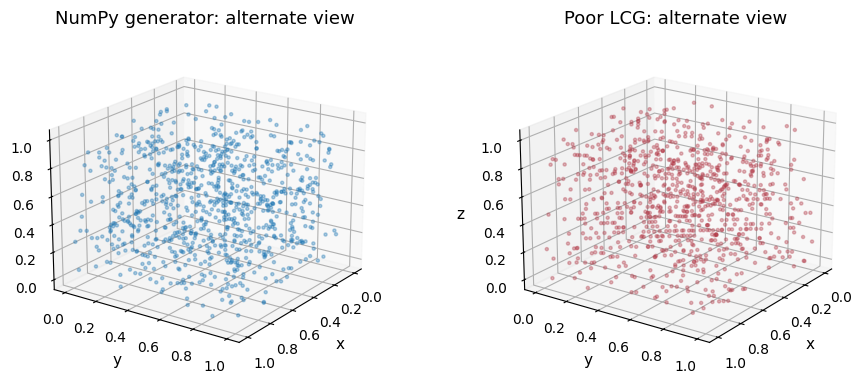

In [4]:
# This cell is intentionally light: it gives a second viewing angle for the same 3D data.
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(121, projection="3d")
ax1.view_init(elev=20, azim=35)
ax1.scatter(good_points[:, 0], good_points[:, 1], good_points[:, 2], s=5, alpha=0.35)
ax1.set_title("NumPy generator: alternate view")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")

ax2 = fig.add_subplot(122, projection="3d")
ax2.view_init(elev=20, azim=35)
ax2.scatter(bad_points[:, 0], bad_points[:, 1], bad_points[:, 2], s=5, alpha=0.35, color="#b23a48")
ax2.set_title("Poor LCG: alternate view")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")
plt.tight_layout()
show_fig()


## 3. Exponential Free Paths and the No-Scattering Limit

For neutron transport, the distance \(s\) to the next interaction follows an exponential distribution,

\[
p(s) = \frac{1}{\lambda}\exp(-s/\lambda),
\]

where \(\lambda\) is the mean free path. Inverse transform sampling gives

\[
s = -\lambda \ln(1-u),
\]

with \(u\) uniformly distributed on \([0,1)\).

In the absence of scattering, attenuation is controlled by the macroscopic absorption cross-section:

\[
\Sigma_a = n\sigma_a, \qquad \lambda_a = \frac{1}{\Sigma_a}.
\]

In [5]:
AVOGADRO = 6.02214076e23
BARN_CM2 = 1.0e-24


@dataclass(frozen=True)
class Material:
    name: str
    sigma_a_barn: float
    sigma_s_barn: float
    density_g_cm3: float
    molar_mass_g_mol: float

    @property
    def number_density(self):
        return self.density_g_cm3 * AVOGADRO / self.molar_mass_g_mol

    @property
    def macro_absorption(self):
        return self.number_density * self.sigma_a_barn * BARN_CM2

    @property
    def macro_scattering(self):
        return self.number_density * self.sigma_s_barn * BARN_CM2

    @property
    def macro_total(self):
        return self.macro_absorption + self.macro_scattering

    @property
    def total_mean_free_path(self):
        return 1.0 / self.macro_total

    @property
    def absorption_mean_free_path(self):
        return 1.0 / self.macro_absorption

    @property
    def absorption_probability_per_collision(self):
        return self.macro_absorption / self.macro_total


materials = {
    "Water": Material("Water", 0.6652, 103.0, 1.00, 18.0153),
    "Lead": Material("Lead", 0.158, 11.221, 11.35, 207.2),
    "Graphite": Material("Graphite", 0.0045, 4.74, 1.67, 12.011),
}


def exponential_samples(rng, mean_free_path, n):
    u = rng.uniform(0.0, 1.0, n)
    return -mean_free_path * np.log(1.0 - u)


def weighted_linear_fit(x, y, sigma_y):
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(sigma_y) & (sigma_y > 0)
    x = x[mask]
    y = y[mask]
    sigma_y = sigma_y[mask]
    weights = 1.0 / sigma_y**2
    design = np.column_stack((x, np.ones_like(x)))
    normal = design.T @ (weights[:, None] * design)
    covariance = np.linalg.inv(normal)
    beta = covariance @ (design.T @ (weights * y))
    return beta[0], beta[1], math.sqrt(covariance[0, 0]), math.sqrt(covariance[1, 1])


def fit_exponential_length(samples, bins=70, min_count=15):
    counts, edges = np.histogram(samples, bins=bins)
    centres = 0.5 * (edges[:-1] + edges[1:])
    mask = counts >= min_count
    log_counts = np.log(counts[mask])
    sigma_log_counts = 1.0 / np.sqrt(counts[mask])
    slope, intercept, slope_err, intercept_err = weighted_linear_fit(
        centres[mask], log_counts, sigma_log_counts
    )
    length = -1.0 / slope
    length_err = slope_err / slope**2
    return {
        "length": length,
        "length_err": length_err,
        "slope": slope,
        "slope_err": slope_err,
        "intercept": intercept,
        "intercept_err": intercept_err,
        "centres": centres,
        "counts": counts,
        "mask": mask,
    }

Theoretical absorption mean free path in water: 44.97 cm
Fitted attenuation length without scattering: 44.98 +/- 0.19 cm


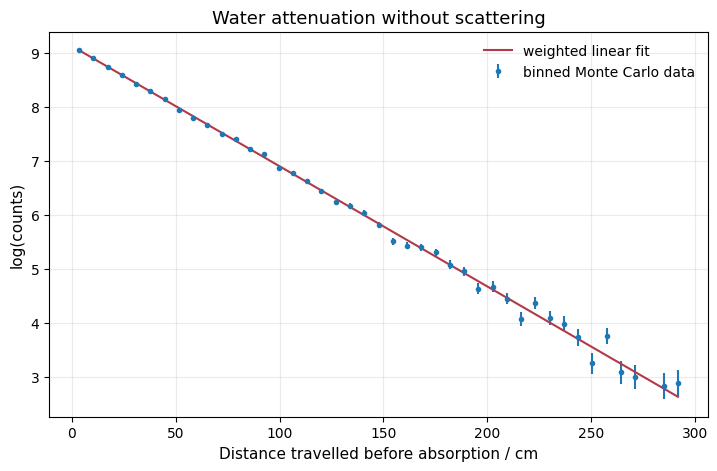

In [6]:
water = materials["Water"]
water_absorption_samples = exponential_samples(RNG, water.absorption_mean_free_path, 60_000)
water_fit = fit_exponential_length(water_absorption_samples)

print(f"Theoretical absorption mean free path in water: {water.absorption_mean_free_path:.2f} cm")
print(
    "Fitted attenuation length without scattering: "
    f"{water_fit['length']:.2f} +/- {water_fit['length_err']:.2f} cm"
)

fig, ax = plt.subplots()
centres = water_fit["centres"]
counts = water_fit["counts"]
mask = water_fit["mask"]
ax.errorbar(centres[mask], np.log(counts[mask]), yerr=1 / np.sqrt(counts[mask]),
            fmt="o", markersize=3, label="binned Monte Carlo data")
x_fit = np.linspace(centres[mask].min(), centres[mask].max(), 200)
y_fit = water_fit["slope"] * x_fit + water_fit["intercept"]
ax.plot(x_fit, y_fit, color="#b23a48", label="weighted linear fit")
ax.set_xlabel("Distance travelled before absorption / cm")
ax.set_ylabel("log(counts)")
ax.set_title("Water attenuation without scattering")
ax.legend()
show_fig()

The fitted value is close to \(45\ \mathrm{cm}\), confirming that the exponential generator and the absorption cross-section conversion are consistent. This is an important validation step before adding scattering, where the path geometry becomes more complex.

## 4. Isotropic Directions and Exponential Steps

A common error is to sample both spherical angles uniformly. That does not produce a uniform distribution on a sphere because area elements depend on \(\sin\theta\). Instead, I sample

\[
\phi \sim U(0,2\pi), \qquad \cos\theta \sim U(-1,1).
\]

The Cartesian unit vector is then

\[
\hat{\mathbf{r}} =
(\sin\theta\cos\phi,\ \sin\theta\sin\phi,\ \cos\theta).
\]

The histogram of \(\cos\theta\) is the most direct quantitative check of isotropy; a flat distribution confirms that directions are uniformly distributed over the sphere.

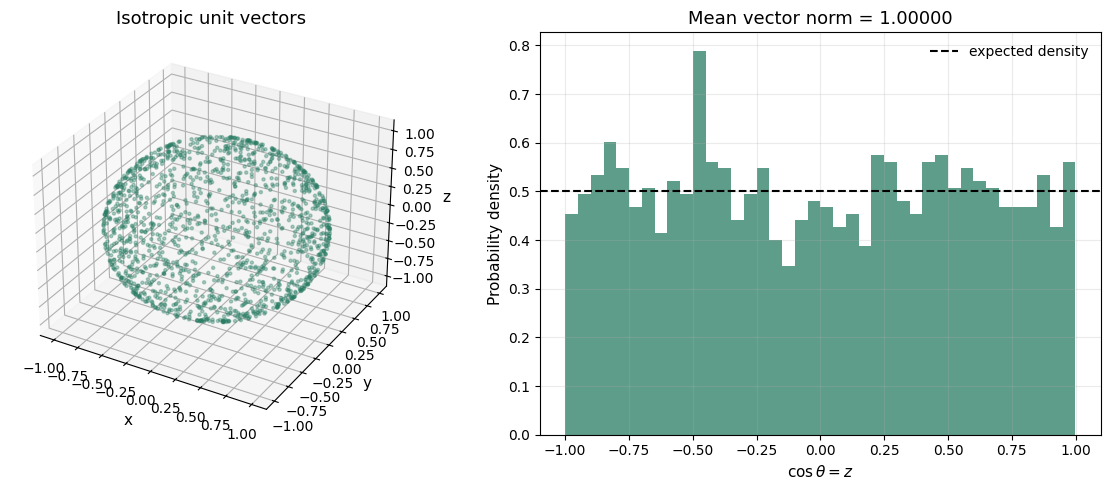

In [7]:
def isotropic_unit_vectors(rng, n):
    phi = rng.uniform(0.0, 2.0 * np.pi, n)
    cos_theta = rng.uniform(-1.0, 1.0, n)
    sin_theta = np.sqrt(1.0 - cos_theta**2)
    return np.column_stack((sin_theta * np.cos(phi), sin_theta * np.sin(phi), cos_theta))


def isotropic_steps(rng, mean_free_path, n):
    lengths = exponential_samples(rng, mean_free_path, n)
    return lengths[:, None] * isotropic_unit_vectors(rng, n)


vectors = isotropic_unit_vectors(RNG, 1_500)
norms = np.linalg.norm(vectors, axis=1)

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection="3d")
ax1.scatter(vectors[:, 0], vectors[:, 1], vectors[:, 2], s=5, alpha=0.35, color="#287c63")
ax1.set_title("Isotropic unit vectors")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")

ax2 = fig.add_subplot(122)
ax2.hist(vectors[:, 2], bins=40, density=True, alpha=0.75, color="#287c63")
ax2.axhline(0.5, color="black", linestyle="--", label="expected density")
ax2.set_xlabel(r"$\cos\theta = z$")
ax2.set_ylabel("Probability density")
ax2.set_title(f"Mean vector norm = {norms.mean():.5f}")
ax2.legend()
plt.tight_layout()
show_fig()


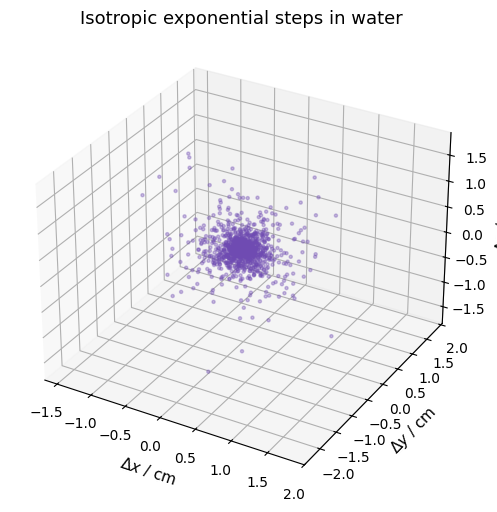

In [8]:
water_steps = isotropic_steps(RNG, water.total_mean_free_path, 1_500)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(water_steps[:, 0], water_steps[:, 1], water_steps[:, 2],
           s=5, alpha=0.35, color="#6f4bb2")
ax.set_title("Isotropic exponential steps in water")
ax.set_xlabel(r"$\Delta x$ / cm")
ax.set_ylabel(r"$\Delta y$ / cm")
ax.set_zlabel(r"$\Delta z$ / cm")
show_fig()


The same optional 3D check can also be used for isotropic unit vectors by setting the flag below to `True`. The quantitative check used for the main run is the flat \(\cos\theta\) histogram, which is less expensive and more objective than judging a dense 3D plot by eye.

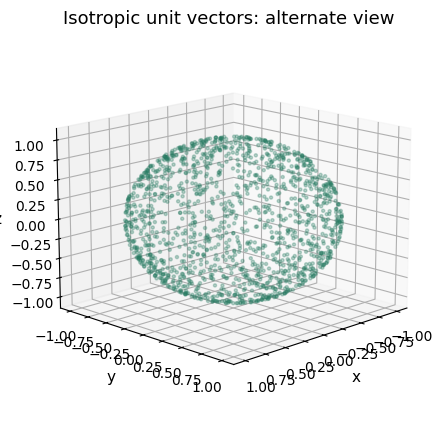

In [9]:
# A second view of the isotropic vector cloud helps check that the apparent density
# is not a viewing-angle artefact.
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")
ax.view_init(elev=15, azim=45)
ax.scatter(vectors[:, 0], vectors[:, 1], vectors[:, 2],
           s=5, alpha=0.30, color="#287c63")
ax.set_title("Isotropic unit vectors: alternate view")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
show_fig()


## 5. Material Properties

The microscopic cross-sections in barns are converted into macroscopic cross-sections using

\[
\Sigma = n\sigma, \qquad n = \frac{\rho N_A}{M}.
\]

The total interaction coefficient is

\[
\Sigma_t = \Sigma_a + \Sigma_s,
\]

so the total mean free path is \(\lambda_t = 1/\Sigma_t\). At each collision, the probability of absorption is \(\Sigma_a/\Sigma_t\); otherwise the neutron scatters isotropically.

In [10]:
property_rows = []
for material in materials.values():
    property_rows.append({
        "Material": material.name,
        "n / cm^-3": material.number_density,
        "Sigma_a / cm^-1": material.macro_absorption,
        "Sigma_s / cm^-1": material.macro_scattering,
        "Sigma_t / cm^-1": material.macro_total,
        "lambda_t / cm": material.total_mean_free_path,
        "P(absorb collision)": material.absorption_probability_per_collision,
    })

display_table(property_rows)

| Material | n / cm^-3 | Sigma_a / cm^-1 | Sigma_s / cm^-1 | Sigma_t / cm^-1 | lambda_t / cm | P(absorb collision) |
| --- | --- | --- | --- | --- | --- | --- |
| Water | 3.343e+22 | 0.02224 | 3.443 | 3.465 | 0.2886 | 0.006417 |
| Lead | 3.299e+22 | 0.005212 | 0.3702 | 0.3754 | 2.664 | 0.01389 |
| Graphite | 8.373e+22 | 0.0003768 | 0.3969 | 0.3973 | 2.517 | 0.0009485 |

## 6. Neutron Random Walk Through a Slab

The slab occupies \(0 \le x \le L\). Each neutron enters at \(x=0\) travelling in the \(+x\) direction. For each history:

1. Draw a free path from the exponential distribution using \(\lambda_t\).
2. Move the neutron in its current direction.
3. If \(x<0\), classify the neutron as reflected.
4. If \(x>L\), classify it as transmitted.
5. If the neutron remains inside the slab, choose absorption with probability \(\Sigma_a/\Sigma_t\).
6. If not absorbed, scatter isotropically and continue.

This algorithm separates boundary escape from collision physics, which is important because a neutron can leave the material before its next collision.

In [11]:
def trace_neutron(rng, material, thickness, max_steps=20_000):
    position = np.array([0.0, 0.0, 0.0])
    direction = np.array([1.0, 0.0, 0.0])
    path = [position.copy()]

    for _ in range(max_steps):
        step_length = exponential_samples(rng, material.total_mean_free_path, 1)[0]
        position = position + step_length * direction
        path.append(position.copy())

        if position[0] < 0.0:
            return "reflected", np.array(path)
        if position[0] > thickness:
            return "transmitted", np.array(path)
        if rng.uniform() < material.absorption_probability_per_collision:
            return "absorbed", np.array(path)

        direction = isotropic_unit_vectors(rng, 1)[0]

    return "max_steps", np.array(path)


def simulate_slab(rng, material, thickness, n_neutrons, max_steps=20_000):
    counts = {"absorbed": 0, "reflected": 0, "transmitted": 0, "max_steps": 0}

    positions = np.zeros((n_neutrons, 3))
    directions = np.zeros((n_neutrons, 3))
    directions[:, 0] = 1.0

    for _ in range(max_steps):
        active = len(positions)
        if active == 0:
            break

        step_lengths = rng.exponential(material.total_mean_free_path, active)
        positions = positions + step_lengths[:, None] * directions

        reflected = positions[:, 0] < 0.0
        transmitted = positions[:, 0] > thickness
        counts["reflected"] += int(reflected.sum())
        counts["transmitted"] += int(transmitted.sum())

        inside = ~(reflected | transmitted)
        positions = positions[inside]
        directions = directions[inside]
        if len(positions) == 0:
            break

        absorbed = rng.uniform(size=len(positions)) < material.absorption_probability_per_collision
        counts["absorbed"] += int(absorbed.sum())

        scattered = ~absorbed
        positions = positions[scattered]
        directions = isotropic_unit_vectors(rng, len(positions))
    else:
        counts["max_steps"] += len(positions)

    result = {"Material": material.name, "L / cm": thickness, "N": n_neutrons}
    for outcome, count in counts.items():
        fraction = count / n_neutrons
        uncertainty = math.sqrt(fraction * (1.0 - fraction) / n_neutrons)
        result[f"{outcome} fraction"] = fraction
        result[f"{outcome} uncertainty"] = uncertainty
    return result

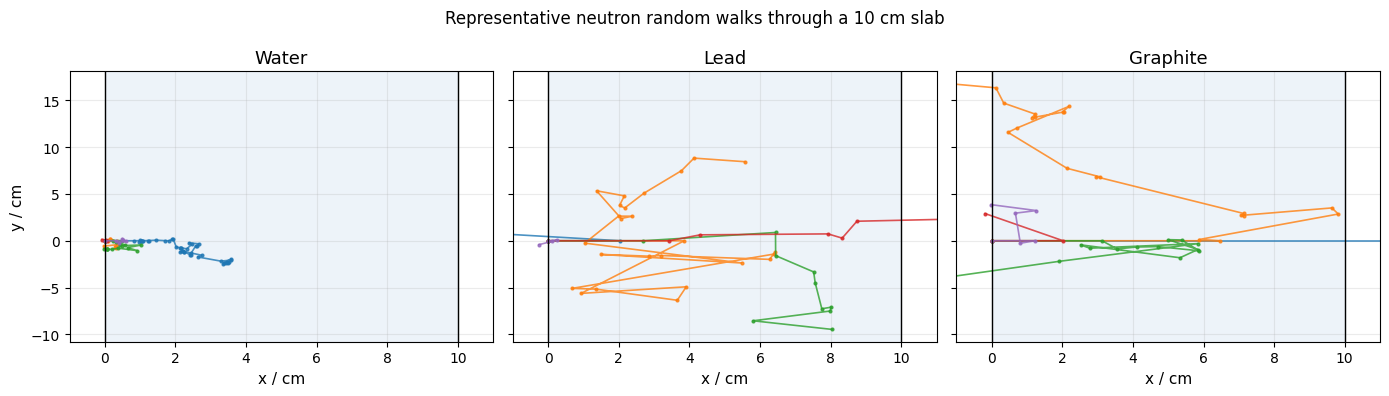

In [12]:
L_example = 10.0

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, material in zip(axes, materials.values()):
    for _ in range(5):
        outcome, path = trace_neutron(RNG, material, L_example)
        ax.plot(path[:, 0], path[:, 1], marker="o", markersize=2, linewidth=1.2, alpha=0.8, label=outcome)
    ax.axvline(0, color="black", linewidth=1)
    ax.axvline(L_example, color="black", linewidth=1)
    ax.axvspan(0, L_example, color="#d8e6f3", alpha=0.45)
    ax.set_title(material.name)
    ax.set_xlabel("x / cm")
    ax.set_xlim(-1, L_example + 1)
axes[0].set_ylabel("y / cm")
plt.suptitle("Representative neutron random walks through a 10 cm slab")
plt.tight_layout()
show_fig()

Water has a very short total mean free path because of its large scattering cross-section. A neutron therefore takes many small steps and is often reflected before it can reach the far side of the slab. Lead and graphite have longer total mean free paths, so transmission through a 10 cm slab is more likely.

## 7. Absorption, Reflection, and Transmission for \(L=10\ \mathrm{cm}\)

Each result is a binomial fraction \(f = N_i/N\), with uncertainty

\[
\sigma_f = \sqrt{\frac{f(1-f)}{N}}.
\]

The following simulation uses enough neutrons to give stable results while keeping the full notebook runtime below the project target.

In [13]:
N_MAIN = 2_500
rates_10cm = [simulate_slab(RNG, material, 10.0, N_MAIN) for material in materials.values()]
display_table(rates_10cm)

| Material | L / cm | N | absorbed fraction | absorbed uncertainty | reflected fraction | reflected uncertainty | transmitted fraction | transmitted uncertainty | max_steps fraction | max_steps uncertainty |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Water | 10 | 2500 | 0.196 | 0.007939 | 0.7996 | 0.008006 | 0.0044 | 0.001324 | 0 | 0 |
| Lead | 10 | 2500 | 0.0988 | 0.005968 | 0.628 | 0.009667 | 0.2732 | 0.008912 | 0 | 0 |
| Graphite | 10 | 2500 | 0.008 | 0.001782 | 0.6944 | 0.009213 | 0.2976 | 0.009144 | 0 | 0 |

The three fractions should sum to approximately one. Any `max_steps` fraction would indicate a numerical failure; it is expected to be zero for the parameters used here.

## 8. Dependence on Slab Thickness

I now repeat the simulation for a range of slab thicknesses. A thicker slab generally reduces transmission, but the balance between absorption and reflection depends on the material. Strong scattering can increase reflection because neutrons are redirected back out of the entrance surface before being absorbed.

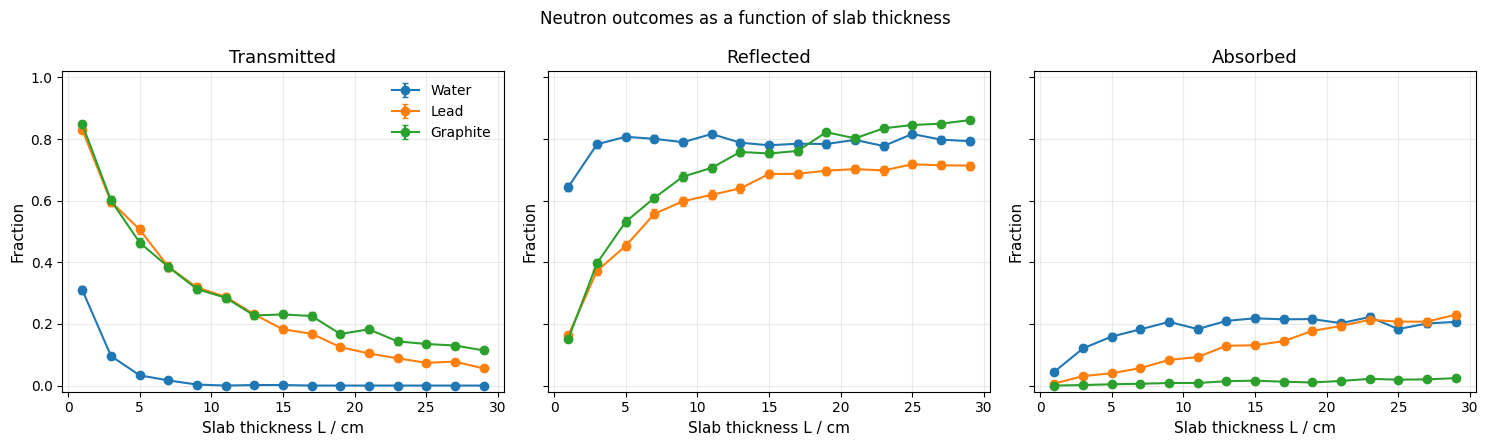

In [14]:
def scan_thicknesses(rng, material, thicknesses, n_neutrons):
    return [simulate_slab(rng, material, float(L), n_neutrons) for L in thicknesses]


thicknesses = np.arange(1.0, 31.0, 2.0)
N_SCAN = 1_200
scan_results = {}

for material in materials.values():
    scan_results[material.name] = scan_thicknesses(RNG, material, thicknesses, N_SCAN)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
quantities = ["transmitted", "reflected", "absorbed"]

for ax, quantity in zip(axes, quantities):
    for material in materials.values():
        rows = scan_results[material.name]
        y = np.array([row[f"{quantity} fraction"] for row in rows])
        yerr = np.array([row[f"{quantity} uncertainty"] for row in rows])
        ax.errorbar(thicknesses, y, yerr=yerr, marker="o", capsize=2, label=material.name)
    ax.set_title(quantity.capitalize())
    ax.set_xlabel("Slab thickness L / cm")
    ax.set_ylabel("Fraction")
    ax.set_ylim(-0.02, 1.02)
axes[0].legend()
plt.suptitle("Neutron outcomes as a function of slab thickness")
plt.tight_layout()
show_fig()

## 9. Characteristic Attenuation Lengths from Transmission

The transmitted fraction is fitted to

\[
T(L) = T_0 \exp(-L/\lambda_\mathrm{att}).
\]

Taking logarithms gives a straight-line fit:

\[
\ln T = \ln T_0 - \frac{L}{\lambda_\mathrm{att}}.
\]

Thickness values with zero transmitted neutrons are removed before fitting because \(\ln(0)\) is undefined. The uncertainty in \(\ln T\) is propagated as \(\sigma_{\ln T}=\sigma_T/T\).

| Material | attenuation length / cm | uncertainty / cm | valid fit points |
| --- | --- | --- | --- |
| Water | 2.002 | 0.08345 | 7 |
| Lead | 9.864 | 0.145 | 15 |
| Graphite | 12.34 | 0.1851 | 15 |

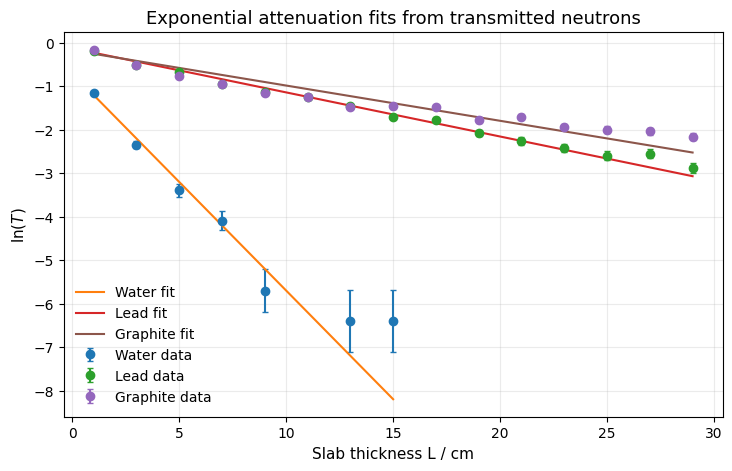

In [15]:
def fit_attenuation_from_transmission(rows):
    thickness = np.array([row["L / cm"] for row in rows], dtype=float)
    transmission = np.array([row["transmitted fraction"] for row in rows], dtype=float)
    sigma_transmission = np.array([row["transmitted uncertainty"] for row in rows], dtype=float)
    mask = (transmission > 0.0) & (sigma_transmission > 0.0)

    log_transmission = np.log(transmission[mask])
    sigma_log_transmission = sigma_transmission[mask] / transmission[mask]
    slope, intercept, slope_err, intercept_err = weighted_linear_fit(
        thickness[mask], log_transmission, sigma_log_transmission
    )
    attenuation_length = -1.0 / slope
    attenuation_error = slope_err / slope**2
    return {
        "attenuation length / cm": attenuation_length,
        "attenuation uncertainty / cm": attenuation_error,
        "slope": slope,
        "slope uncertainty": slope_err,
        "intercept": intercept,
        "valid fit points": mask.sum(),
        "mask": mask,
    }


attenuation_rows = []
fig, ax = plt.subplots()

for material in materials.values():
    rows = scan_results[material.name]
    fit = fit_attenuation_from_transmission(rows)
    attenuation_rows.append({
        "Material": material.name,
        "attenuation length / cm": fit["attenuation length / cm"],
        "uncertainty / cm": fit["attenuation uncertainty / cm"],
        "valid fit points": fit["valid fit points"],
    })

    transmission = np.array([row["transmitted fraction"] for row in rows])
    sigma_transmission = np.array([row["transmitted uncertainty"] for row in rows])
    mask = fit["mask"]
    ax.errorbar(thicknesses[mask], np.log(transmission[mask]),
                yerr=sigma_transmission[mask] / transmission[mask],
                marker="o", linestyle="", capsize=2, label=f"{material.name} data")
    x_fit = np.linspace(thicknesses[mask].min(), thicknesses[mask].max(), 200)
    ax.plot(x_fit, fit["slope"] * x_fit + fit["intercept"], label=f"{material.name} fit")

display_table(attenuation_rows)
ax.set_xlabel("Slab thickness L / cm")
ax.set_ylabel(r"$\ln(T)$")
ax.set_title("Exponential attenuation fits from transmitted neutrons")
ax.legend()
show_fig()

The fitted attenuation length is not simply the total mean free path. Transmission through a finite slab is affected by both collisions and random-walk geometry. A material with strong scattering can have a much shorter transmission attenuation length than its absorption length because many neutrons are reflected back out of the slab.

## 10. Stretch Task: Woodcock Tracking for Two Adjacent Slabs

For two adjacent materials, direct tracking requires changing the total mean free path when the neutron crosses the interface. Woodcock tracking avoids this by sampling candidate collisions from a single majorant cross-section

\[
\Sigma_M = \max(\Sigma_{t,1}, \Sigma_{t,2}).
\]

At a candidate collision, the event is accepted with probability \(\Sigma_t(x)/\Sigma_M\). If rejected, it is a virtual collision and the neutron continues unchanged. This is useful when the material changes along the path.

I validate the implementation by comparing a two-slab calculation where both slabs are the same material with a direct single-slab calculation of double thickness. These two calculations should agree within Monte Carlo uncertainty.

In [16]:
def simulate_two_slab_woodcock(
    rng,
    left_material,
    right_material,
    left_thickness=10.0,
    right_thickness=10.0,
    n_neutrons=1_500,
    max_steps=50_000,
):
    total_thickness = left_thickness + right_thickness
    majorant = max(left_material.macro_total, right_material.macro_total)
    counts = {"absorbed": 0, "reflected": 0, "transmitted": 0, "max_steps": 0}

    positions = np.zeros((n_neutrons, 3))
    directions = np.zeros((n_neutrons, 3))
    directions[:, 0] = 1.0

    for _ in range(max_steps):
        active = len(positions)
        if active == 0:
            break

        positions = positions + rng.exponential(1.0 / majorant, active)[:, None] * directions
        x = positions[:, 0]

        reflected = x < 0.0
        transmitted = x > total_thickness
        counts["reflected"] += int(reflected.sum())
        counts["transmitted"] += int(transmitted.sum())

        inside = ~(reflected | transmitted)
        positions = positions[inside]
        directions = directions[inside]
        if len(positions) == 0:
            break

        in_left = positions[:, 0] <= left_thickness
        macro_total = np.where(in_left, left_material.macro_total, right_material.macro_total)
        absorption_probability = np.where(
            in_left,
            left_material.absorption_probability_per_collision,
            right_material.absorption_probability_per_collision,
        )

        real_collision = rng.uniform(size=len(positions)) < (macro_total / majorant)
        absorbed = real_collision & (rng.uniform(size=len(positions)) < absorption_probability)
        counts["absorbed"] += int(absorbed.sum())

        surviving = ~absorbed
        directions = directions[surviving]
        scattered = real_collision[surviving]
        if scattered.any():
            directions[scattered] = isotropic_unit_vectors(rng, int(scattered.sum()))
        positions = positions[surviving]
    else:
        counts["max_steps"] += len(positions)

    result = {"N": n_neutrons}
    for outcome, count in counts.items():
        fraction = count / n_neutrons
        result[f"{outcome} fraction"] = fraction
        result[f"{outcome} uncertainty"] = math.sqrt(fraction * (1.0 - fraction) / n_neutrons)
    return result


woodcock_cases = [
    ("Water + Lead", materials["Water"], materials["Lead"]),
    ("Lead + Graphite", materials["Lead"], materials["Graphite"]),
    ("Water + Graphite", materials["Water"], materials["Graphite"]),
]

woodcock_rows = []
for label, left, right in woodcock_cases:
    row = simulate_two_slab_woodcock(RNG, left, right)
    row["Case"] = label
    woodcock_rows.append(row)

display_table(woodcock_rows)

| N | absorbed fraction | absorbed uncertainty | reflected fraction | reflected uncertainty | transmitted fraction | transmitted uncertainty | max_steps fraction | max_steps uncertainty | Case |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1500 | 0.1987 | 0.0103 | 0.7993 | 0.01034 | 0.002 | 0.001154 | 0 | 0 | Water + Lead |
| 1500 | 0.144 | 0.009065 | 0.706 | 0.01176 | 0.15 | 0.00922 | 0 | 0 | Lead + Graphite |
| 1500 | 0.1927 | 0.01018 | 0.804 | 0.01025 | 0.003333 | 0.001488 | 0 | 0 | Water + Graphite |

In [17]:
N_VALIDATE = 1_500
direct_water_20 = simulate_slab(RNG, materials["Water"], 20.0, N_VALIDATE)
woodcock_water_water = simulate_two_slab_woodcock(
    RNG, materials["Water"], materials["Water"], 10.0, 10.0, N_VALIDATE
)

validation_rows = []
for outcome in ["absorbed", "reflected", "transmitted"]:
    direct = direct_water_20[f"{outcome} fraction"]
    woodcock = woodcock_water_water[f"{outcome} fraction"]
    combined_uncertainty = math.sqrt(
        direct_water_20[f"{outcome} uncertainty"]**2
        + woodcock_water_water[f"{outcome} uncertainty"]**2
    )
    validation_rows.append({
        "Outcome": outcome,
        "Direct 20 cm water": direct,
        "Woodcock 10+10 cm water": woodcock,
        "absolute difference": abs(direct - woodcock),
        "combined uncertainty": combined_uncertainty,
    })

display_table(validation_rows)

| Outcome | Direct 20 cm water | Woodcock 10+10 cm water | absolute difference | combined uncertainty |
| --- | --- | --- | --- | --- |
| absorbed | 0.206 | 0.204 | 0.002 | 0.01474 |
| reflected | 0.794 | 0.796 | 0.002 | 0.01474 |
| transmitted | 0 | 0 | 0 | 0 |

The validation checks the algorithm rather than the physics of a new material combination. If the direct and Woodcock estimates differ by an amount comparable to their combined uncertainty, the majorant sampling and virtual-collision logic are behaving correctly.

## Brief Checklist

The required stages have been completed: uniform random-number testing, spectral artefact demonstration, exponential free-path generation, the water no-scattering attenuation check, isotropic directions, isotropic exponential steps, material-property calculation, slab random walks, 10 cm outcome rates with uncertainties, thickness scans, attenuation-length fits, and the Woodcock two-slab extension.


## Conclusion

This notebook developed a Monte Carlo model for thermal neutron transport through water, lead, and graphite. The random-number checks show why high-quality multidimensional sampling is needed. The no-scattering water calculation reproduces an attenuation length close to \(45\ \mathrm{cm}\), validating the exponential free-path generator and cross-section conversion.

When scattering is included, neutron transport becomes a random-walk problem rather than a simple exponential absorption problem. Water strongly scatters neutrons, producing high reflection and low transmission for a 10 cm slab. Lead and graphite have longer total mean free paths, so a larger fraction of neutrons can be transmitted through the same thickness. The fitted transmission attenuation lengths therefore include both interaction physics and slab geometry.

Finally, Woodcock tracking provides a flexible method for adjacent slabs of different materials. The same-material validation gives a direct check that the two-region algorithm is consistent with the single-slab simulation.

In [18]:
runtime = time.perf_counter() - start_time
print(f"Notebook runtime: {runtime:.2f} s")

Notebook runtime: 4.67 s
